In [139]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv(r"C:\Users\jiten\OneDrive\Desktop\python\data_set\smartcart_customers.csv")

#handel missing value
df['Income'] =  df['Income'].fillna(df['Income'].median())

#feature Engineering
df['Age'] = 2026- df['Year_Birth']
df.head()
#customer Joining Date

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst=True)
reference_date = df['Dt_Customer'].max()

df['Cusomer_Tenure_days'] = (reference_date -df['Dt_Customer']).dt.days



data size with outliers: 2240
data size without outliers: 2236


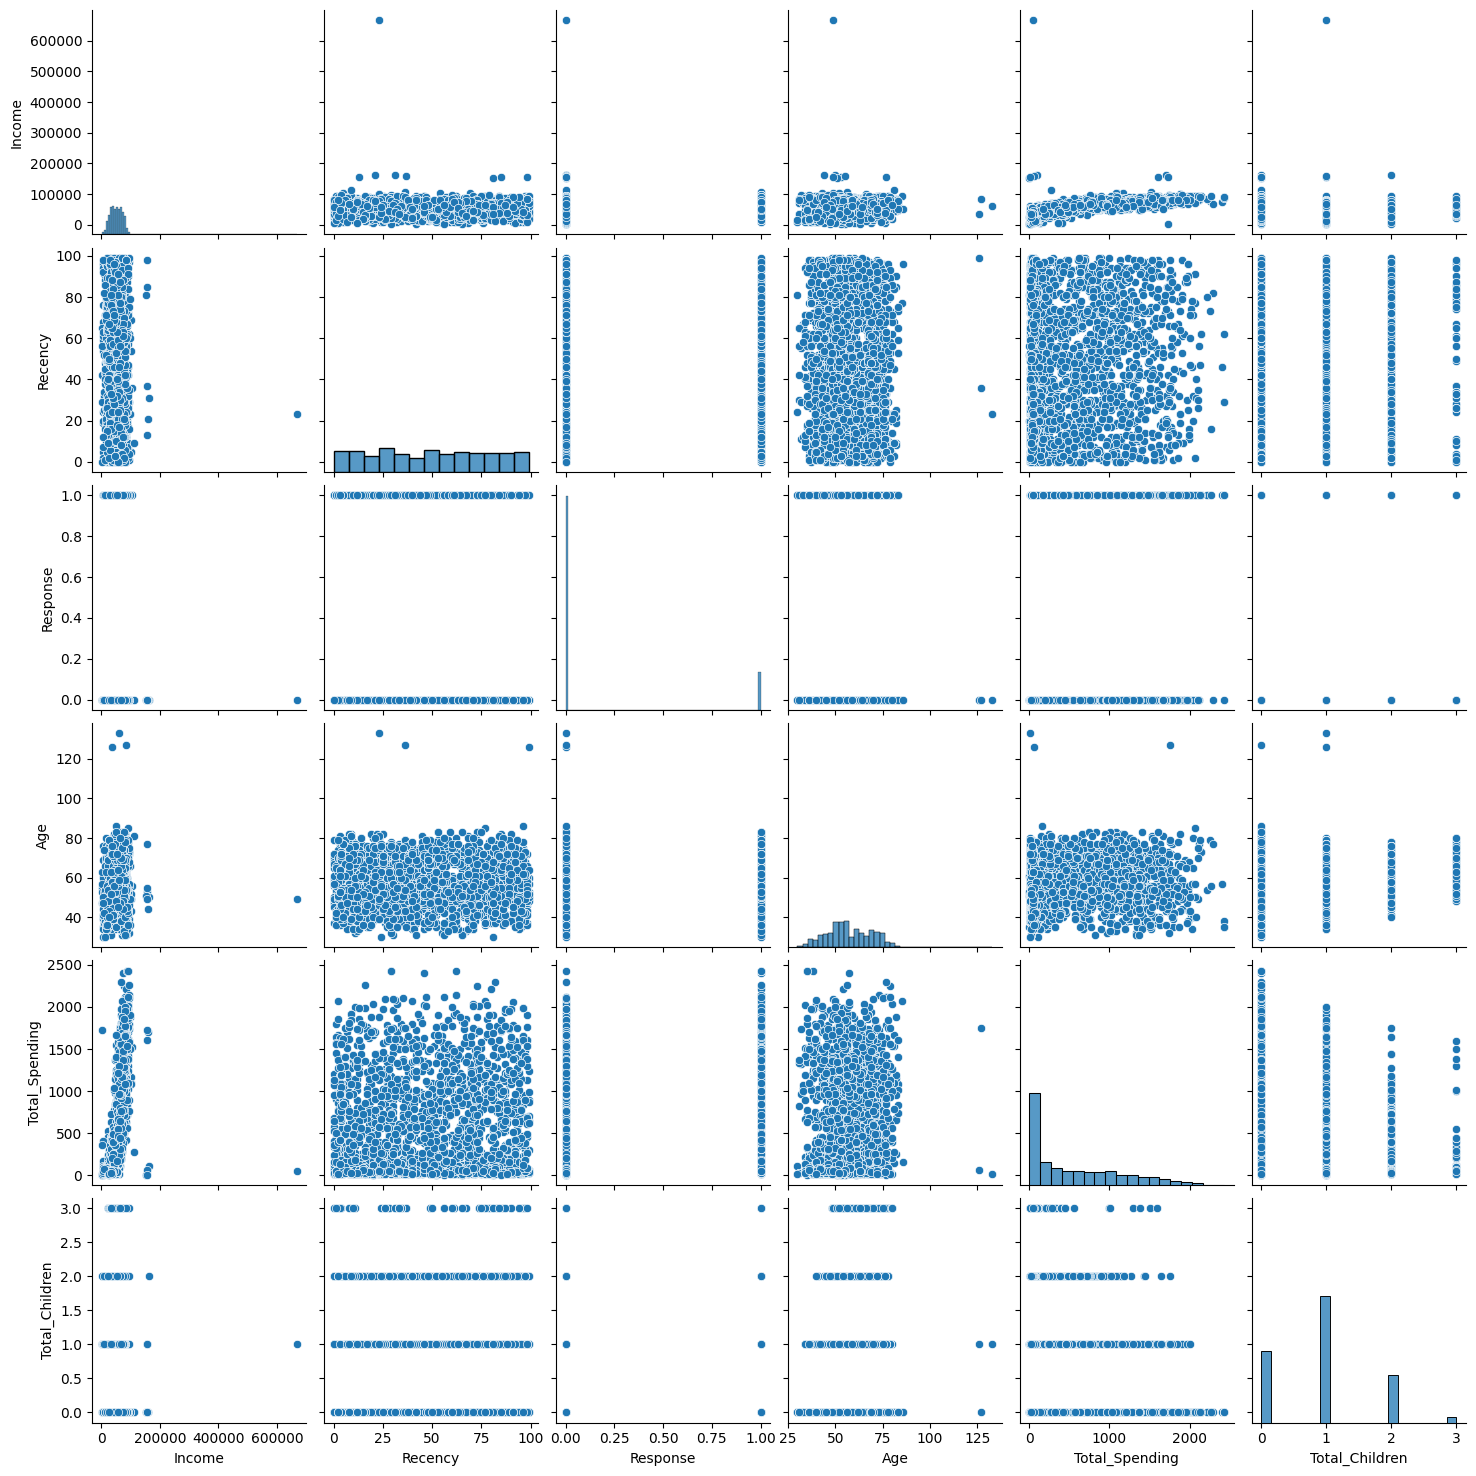

In [140]:
#Spending
df['Total_Spending'] = df['MntWines'] +df['MntFruits'] + df['MntMeatProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
#Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
#Educations
df['Education'] = df['Education'].replace({
    "Basic" : "Undergraduate" , "2n Cycle" :"Undergraduate",
    "Graduation":"Graduate",
    "Master ": "Postgraduate" , "phD": "Postgraduate"

})
#marital_Status
df['Living_With'] = df['Marital_Status'].replace({
    "Married":"Partner" , "Together" :"Partner",
    "Single" :'Alone' ,"Divorced":'Alone',
    'Widow ' : 'Alone' , 'Absurd' :'Alone' , 'YOLD' :'Alone'
})

#Drop Status
cols = ["ID" , "Year_Birth" , "Marital_Status" , "Kidhome" ,'Teenhome' , "Dt_Customer"]
spending_cols = ["MntWines","MntFruits" , "MntMeatProducts" , "MntFishProducts" ,"MntSweetProducts" , "MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns= cols_to_drop)

#Outliers
cols = ["Income" , "Recency" ,"Response" ,"Age" ,"Total_Spending" , "Total_Children"]
#relative plots of some features - pair Plots
sns.pairplot(df_cleaned[cols])

#removes the Outliers
print("data size with outliers:" , len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

print("data size without outliers:" ,len(df_cleaned))


c:\Users\jiten\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


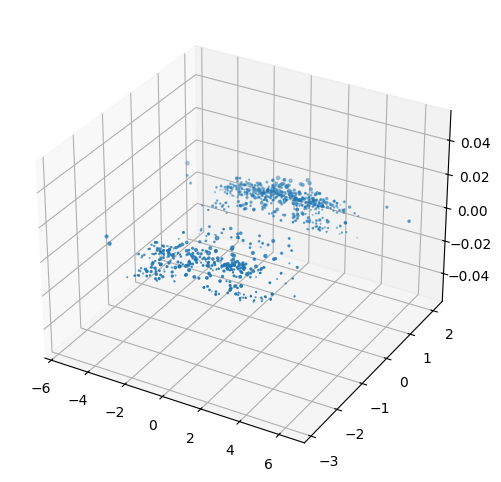

In [141]:
#Encoding
ohe = OneHotEncoder()
cat_cols = ["Education" , "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray() , columns= ohe.get_feature_names_out(cat_cols) , index=df_cleaned.index)
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

#Scaling
X = df_encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Visualize
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111 , projection="3d")
plt.scatter(X_pca[:,0], X_pca[:,1] , X_pca[:,2])



best k =  4


Text(0, 0.5, 'ss')

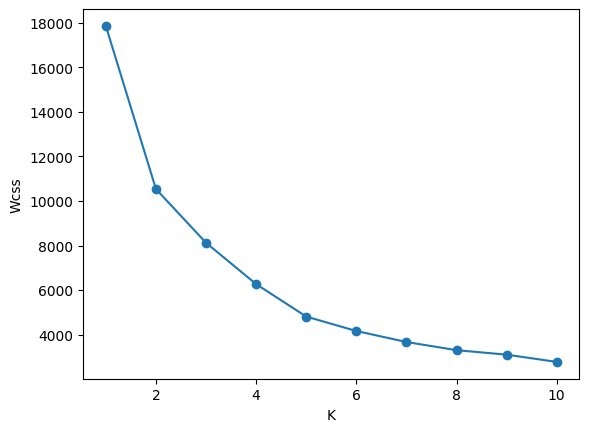

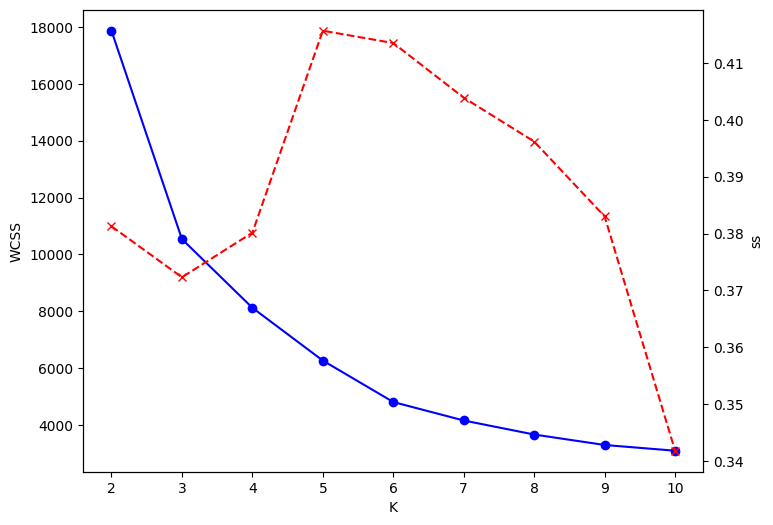

In [ ]:
#Elbow method
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1,11):
    Kmeans = KMeans(n_clusters=k , random_state=42)
    Kmeans.fit_predict(X_pca)
    wcss.append(Kmeans.inertia_)

knee = KneeLocator(range(1,11), wcss, curve="convex" , direction="decreasing")
optimal_k = knee.elbow
print("best k = ", optimal_k)
plt.plot(range(1,11), wcss , marker = 'o')
plt.xlabel("K")
plt.ylabel("Wcss")

#silhouette Score

from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    Kmeans = KMeans(n_clusters=k, random_state=42)
    labels = Kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)

#compined plot
K_range= range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(K_range, wcss[:len(K_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2 = ax1.twinx()
ax2.plot(K_range , scores[:len(K_range)], marker='x' , color = "red" , linestyle ="--")
ax2.set_ylabel("ss")




<Axes: xlabel='cluster', ylabel='count'>

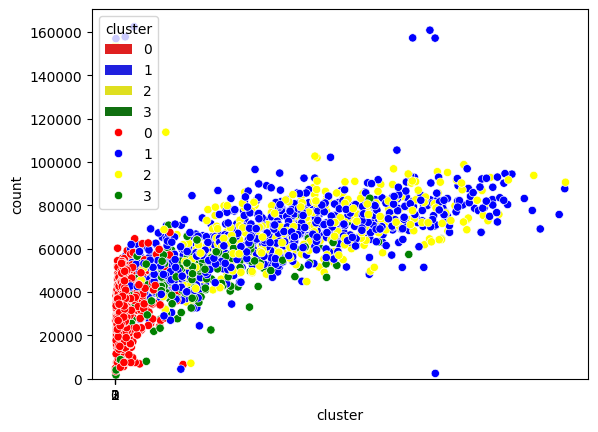

In [148]:
#kmeans

Kmeans = KMeans(n_clusters=4 , random_state=42)
labels_kmeans = Kmeans.fit_predict(X_pca)
fig = plt.Figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0] ,X_pca[:,1] , X_pca[:,2] , c = labels_kmeans)

#Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=4 , linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.Figure(figsize=(8,6))

ax = fig.add_subplot(111 , projection="3d")
ax.scatter(X_pca[:,0] , X_pca[:,1] ,X_pca[:,2], c = labels_kmeans)
X["cluster"] = labels_agg
pal = ["red" , "blue" ,"yellow" , "green"]
sns.countplot(x = X["cluster"] , palette=pal , hue=X['cluster'])
#income & Spending Pattens

sns.scatterplot(x=X['Total_Spending'] , y=X['Income'] , hue=X['cluster'] ,palette=pal)

In [146]:
#cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        32361.312872  49.375447           1.861740         1.820024   
1        65775.548507  49.630597           2.115672         5.309701   
2        69077.183377  50.221636           1.815303         5.638522   
3        46500.514019  44.210280           5.841121         5.640187   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.387366           2.992849           6.554231  0.011919   
1                   4.266169           7.675373           4.087065  0.007463   
2                   4.751979           8.195251           3.881266  0.005277   
3                   1.864486           5.471963           7.649533  0.009346   

         Response        Age  ...  Total_Spending  Total_Children  \
cluster          